In [5]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
#importing the necessary Libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import nltk
import seaborn as sns
from nltk.corpus import stopwords
import string
from nltk.stem import PorterStemmer
from wordcloud import WordCloud
from collections import Counter
from sklearn. feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

In [9]:
#reading the CSV file
x = pd.read_csv("new.csv")
#displaying the dataframe
x


,Label,Message
0,spam,"Dear Student, Its never too late-clear your ba..."
1,spam,Join V-STUDY and score excellent marks in clas...
2,spam,"Join crash courses for B.ST,A/C'S,ECO,ENG,&IP ..."
3,spam,CRASH COURSES by BEST POOL OF FACULTY. ENGLISH...
4,ham,"Dear Ola Shuttle user, get 60% Off on your nex..."
...,...,...
179,spam,"SPOT ADMISSIONS FOR FORENSIC SCIENCE, Cardiac ..."
180,spam,"CBSE Private Exam 2018, Forms are starting for..."
181,spam,If you receive offer of lottery winnings or ch...
182,spam,Gokul sent you a Blue Packet which expires in ...


In [11]:
x.shape

(184, 2)

In [13]:
# printing the concise summary of the dataset
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Label    184 non-null    object
 1   Message  184 non-null    object
dtypes: object(2)
memory usage: 3.0+ KB


In [19]:
x.rename(columns={'Label':'result','Message':'Input'},inplace=True)
x

,result,Input
0,spam,"Dear Student, Its never too late-clear your ba..."
1,spam,Join V-STUDY and score excellent marks in clas...
2,spam,"Join crash courses for B.ST,A/C'S,ECO,ENG,&IP ..."
3,spam,CRASH COURSES by BEST POOL OF FACULTY. ENGLISH...
4,ham,"Dear Ola Shuttle user, get 60% Off on your nex..."
...,...,...
179,spam,"SPOT ADMISSIONS FOR FORENSIC SCIENCE, Cardiac ..."
180,spam,"CBSE Private Exam 2018, Forms are starting for..."
181,spam,If you receive offer of lottery winnings or ch...
182,spam,Gokul sent you a Blue Packet which expires in ...


In [21]:
encoder = LabelEncoder()
x['result'] = encoder.fit_transform(x['result'])
x.head()

,result,Input
0,1,"Dear Student, Its never too late-clear your ba..."
1,1,Join V-STUDY and score excellent marks in clas...
2,1,"Join crash courses for B.ST,A/C'S,ECO,ENG,&IP ..."
3,1,CRASH COURSES by BEST POOL OF FACULTY. ENGLISH...
4,0,"Dear Ola Shuttle user, get 60% Off on your nex..."


In [23]:
x.isnull().sum()

result    0
Input     0
dtype: int64

In [25]:
x.duplicated().sum()

12

In [29]:
x=x.drop_duplicates(keep='first')
x

,result,Input
0,1,"Dear Student, Its never too late-clear your ba..."
1,1,Join V-STUDY and score excellent marks in clas...
2,1,"Join crash courses for B.ST,A/C'S,ECO,ENG,&IP ..."
3,1,CRASH COURSES by BEST POOL OF FACULTY. ENGLISH...
4,0,"Dear Ola Shuttle user, get 60% Off on your nex..."
...,...,...
178,1,Looking to get a great Score & Rank in JEEMain...
179,1,"SPOT ADMISSIONS FOR FORENSIC SCIENCE, Cardiac ..."
180,1,"CBSE Private Exam 2018, Forms are starting for..."
181,1,If you receive offer of lottery winnings or ch...


In [31]:
x['result'].value_counts()

1    97
0    75
Name: result, dtype: int64

In [33]:
97*100/172

56.395348837209305

In [35]:
# 56 percent are spam and the rest are not spam

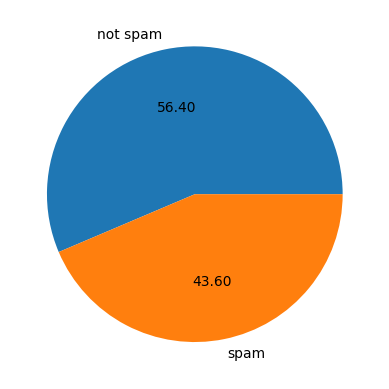

In [37]:
plt.pie(x['result'].value_counts(),labels=['not spam','spam'],autopct='%0.2f')
plt.show()

In [39]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\varsh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [43]:
# creating a new column with count of characters
x['countCharacters']=x['Input'].apply(len)

#creating a new column with count of words 
x['countWords'] = x['Input']. apply(lambda i : len(nltk. word_tokenize(i)))
#'word_tokenize' function takes a string of text as input and returns a list of words

#creating a new column with count of sentences
x['countSentences'] = x['Input'].apply(lambda i: len(nltk.sent_tokenize(i)))
#'sent tokenize' function takes a string of text as input and returns a list of sentences


In [47]:
x.head()

,result,Input,countCharacters,countWords,countSentences
0,1,"Dear Student, Its never too late-clear your ba...",283,49,1
1,1,Join V-STUDY and score excellent marks in clas...,305,59,2
2,1,"Join crash courses for B.ST,A/C'S,ECO,ENG,&IP ...",154,33,2
3,1,CRASH COURSES by BEST POOL OF FACULTY. ENGLISH...,280,60,3
4,0,"Dear Ola Shuttle user, get 60% Off on your nex...",125,30,4


In [51]:
# extracting summary of 3 new columns
x[['countCharacters','countWords','countSentences']].describe()

,countCharacters,countWords,countSentences
count,172.000000,172.000000,172.000000
mean,117.011628,23.889535,2.383721
std,69.835646,13.573905,1.326020
min,3.000000,1.000000,1.000000
25%,47.000000,12.000000,1.000000
50%,134.500000,25.000000,2.000000
75%,155.000000,32.000000,3.000000
max,306.000000,60.000000,7.000000


In [57]:
# for not spam
x[x['result']==0][['countCharacters','countWords','countSentences']].describe()

,countCharacters,countWords,countSentences
count,75.000000,75.000000,75.000000
mean,64.280000,14.200000,1.840000
std,56.035114,11.387523,1.162941
min,3.000000,1.000000,1.000000
25%,19.000000,5.500000,1.000000
50%,41.000000,9.000000,1.000000
75%,108.000000,23.000000,2.000000
max,274.000000,52.000000,5.000000


In [59]:
# for spam
x[x['result']==1][['countCharacters','countWords','countSentences']].describe()

,countCharacters,countWords,countSentences
count,97.000000,97.000000,97.000000
mean,157.783505,31.381443,2.804124
std,49.140578,9.908375,1.296142
min,44.000000,5.000000,1.000000
25%,134.000000,26.000000,2.000000
50%,153.000000,30.000000,3.000000
75%,160.000000,34.000000,3.000000
max,306.000000,60.000000,7.000000


<Axes: xlabel='countCharacters', ylabel='Count'>

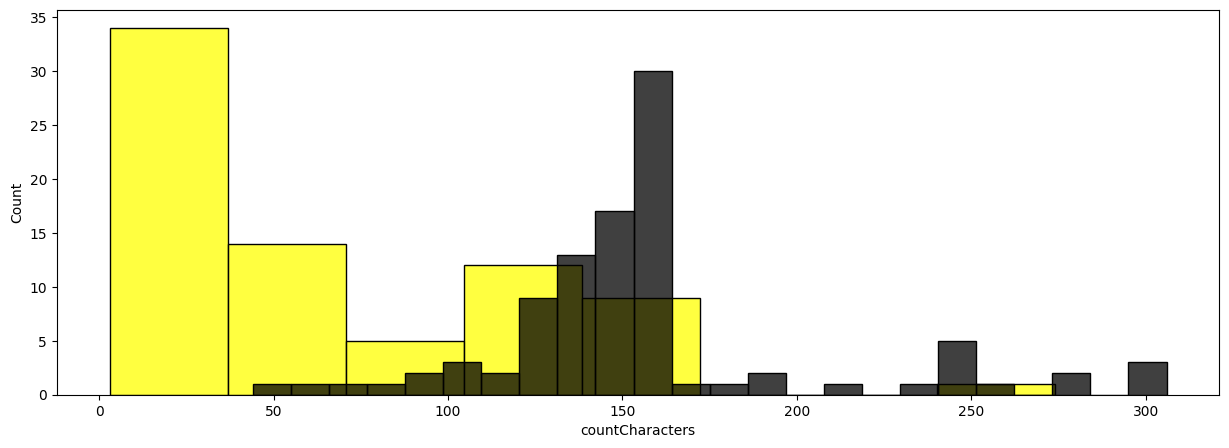

In [63]:
#for better visualization, we will plot a histogram using 'seaborn'
plt.figure(figsize = (15, 5))
sns.histplot(x[x['result' ] == 0][ 'countCharacters' ], color = "yellow")
sns.histplot(x[x['result' ] == 1]['countCharacters' ], color = "black")
#black -> SPAM, yellow -> not SPAM


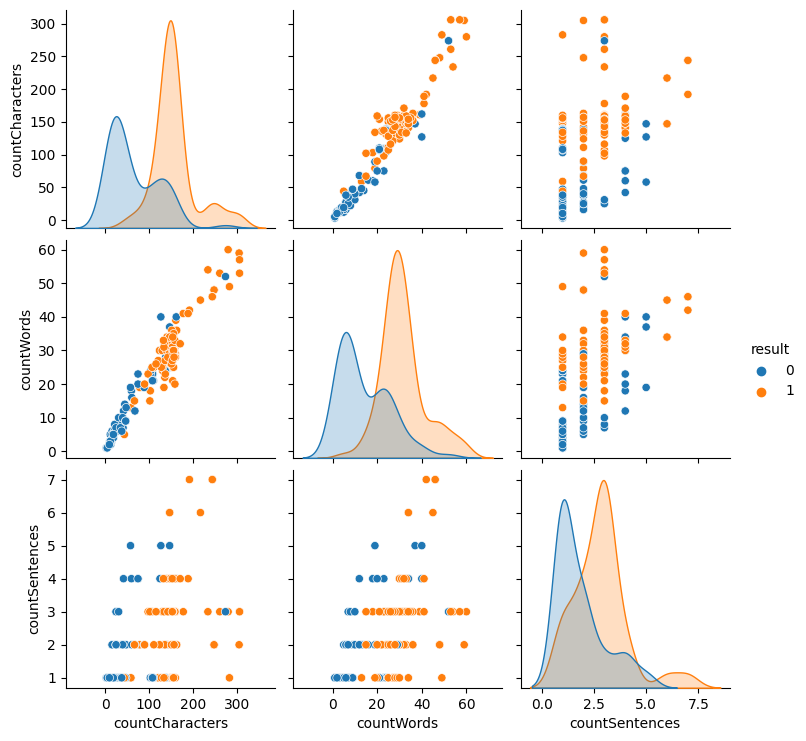

In [65]:
sns.pairplot(x,hue='result')

In [69]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\varsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [83]:
def transform_text (text):
#converting to Lower case
    text = text.lower()
#tokenization
    text = nltk.word_tokenize(text)
#removing special characters
    removedSC = list()
    for i in text:
        if i.isalnum():
            removedSC. append(i)
#updating the text after removed special characters
        text = removedSC[:]
#removing stop words and punctuation characters
    removedSWPC = list()
    for i in text:
    #stopwords. words ('english') is a function of 'nitk', returns List of english stop words
    #string. punctuation is a part of 'string' module, containing the ASCII punctuation characters
        if i not in stopwords.words( 'english') and i not in string.punctuation:
            removedSWPC. append(i)
#updating the text after removed stop words and punctuation characters
    text = removedSWPC[ : ]
#stemming the data using 'PorterStemmer' algorithm.
#nltk module provides this class to use.
    ps = PorterStemmer()
    stemmed = list()
    for i in text:
        stemmed.append(ps.stem(i))
    text = stemmed[: ]
    return " ".join(text)



In [85]:
# function for transforming text is ready

In [87]:
# will create a new column to store the transformed text -> 'processed'
x['processed']=x['Input'].apply(transform_text)
# displaying the edited dataframe with a new column  'processed'
x.head()

,result,Input,countCharacters,countWords,countSentences,processed
0,1,"Dear Student, Its never too late-clear your ba...",283,49,1,dear student never hard work daili schedul exp...
1,1,Join V-STUDY and score excellent marks in clas...,305,59,2,join score excel mark class 12th student cover...
2,1,"Join crash courses for B.ST,A/C'S,ECO,ENG,&IP ...",154,33,2,join crash cours eco eng ip fee per sub expd r...
3,1,CRASH COURSES by BEST POOL OF FACULTY. ENGLISH...,280,60,3,crash cours best pool faculti english eng megh...
4,0,"Dear Ola Shuttle user, get 60% Off on your nex...",125,30,4,dear ola shuttl user get 60 next 2 shuttl ride...


In [91]:
wc=WordCloud(width=500,height=500,min_font_size=10,background_color='white')

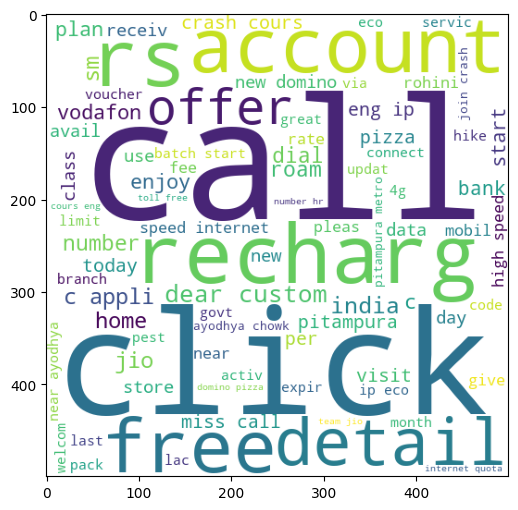

In [93]:
#creating a wordcloud for the SPAM messages
spamWC = wc.generate(x[x['result'] == 1]['processed'].str. cat(sep=" "))
#creating figure and displaying
plt.figure(figsize=(12, 6))
plt.imshow(spamWC)


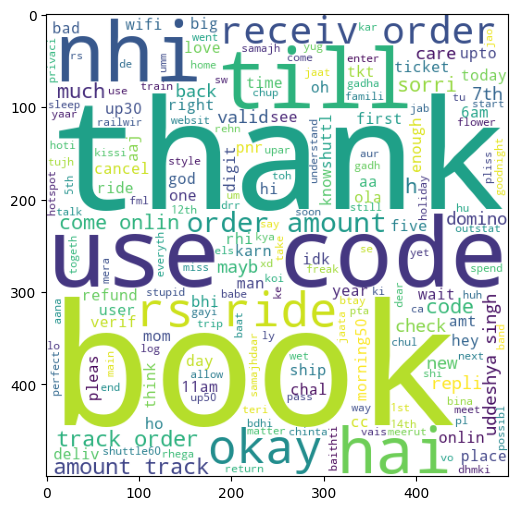

In [95]:
#creating a wordcloud for the not SPAM messages
spamWC = wc.generate(x[x['result'] == 0]['processed'].str. cat(sep=" "))
#creating figure and displaying
plt.figure(figsize=(12, 6))
plt.imshow(spamWC)


In [99]:
#extracting the most common words used in both SPAM and not SPAM messages
#extracting all the words used in SPAM messages
spamWords = list()
for msg in x[x['result'] == 1]['processed']. tolist() :
    for word in msg.split():
        spamWords . append (word)
spamWords


['dear',
 'student',
 'never',
 'hard',
 'work',
 'daili',
 'schedul',
 'expert',
 'also',
 'batch',
 'start',
 'eng',
 'account',
 'ip',
 'eco',
 'branch',
 'rohini',
 'near',
 'ayodhya',
 'chowk',
 'pitampura',
 'branch',
 'near',
 'pitampura',
 'metro',
 '8447841933',
 'join',
 'score',
 'excel',
 'mark',
 'class',
 '12th',
 'student',
 'coverag',
 'assign',
 'class',
 'room',
 'exampl',
 'test',
 'seri',
 'batch',
 'start',
 'eng',
 'ip',
 'account',
 'eco',
 'rohini',
 'near',
 'ayodhya',
 'chowk',
 'near',
 'pitampura',
 'metro',
 'stn',
 'call',
 '8447841933',
 'vidyasagar',
 'institut',
 'join',
 'crash',
 'cours',
 'eco',
 'eng',
 'ip',
 'fee',
 'per',
 'sub',
 'expd',
 'rohini',
 'pitampura',
 'call',
 'crash',
 'cours',
 'best',
 'pool',
 'faculti',
 'english',
 'eng',
 'megha',
 'suri',
 'account',
 'cs',
 'nitin',
 'gupta',
 'eco',
 'cs',
 'nitin',
 'ip',
 'mca',
 'rahul',
 'start',
 'today',
 'fee',
 'rohini',
 'near',
 'ayodhya',
 'chowk',
 'floor',
 'near',
 'pitampura'

In [103]:
#to count the frequency of the words, we will be using the Counter class to create a dictionary
spamWordsDictionary = Counter(spamWords)
#to extract the most common words
spamWordsDictionary.most_common (40)


[('call', 32),
 ('http', 30),
 ('get', 30),
 ('click', 18),
 ('c', 18),
 ('free', 17),
 ('recharg', 16),
 ('rs', 15),
 ('jio', 15),
 ('dear', 14),
 ('account', 14),
 ('number', 14),
 ('custom', 14),
 ('detail', 13),
 ('appli', 13),
 ('offer', 13),
 ('start', 12),
 ('india', 12),
 ('pitampura', 11),
 ('sm', 11),
 ('home', 11),
 ('pizza', 11),
 ('roam', 10),
 ('dial', 10),
 ('new', 10),
 ('eng', 9),
 ('ip', 9),
 ('near', 9),
 ('vodafon', 9),
 ('use', 9),
 ('internet', 9),
 ('enjoy', 9),
 ('plan', 9),
 ('eco', 8),
 ('cours', 8),
 ('bank', 8),
 ('8178390589', 8),
 ('like', 8),
 ('join', 7),
 ('crash', 7)]

In [105]:
#converting this dictionary to a dataframe
mostCommonSPAM = pd.DataFrame(spamWordsDictionary.most_common(40))

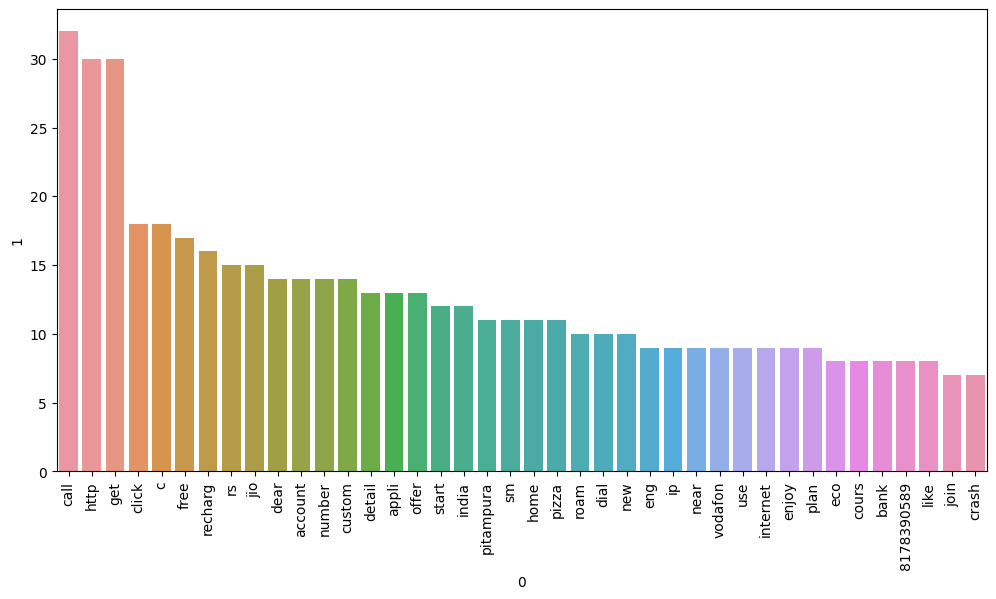

In [107]:
#plotting a bar plot of the mostCommonSPAM dataframe
plt.figure(figsize=(12, 6))
sns.barplot(data = mostCommonSPAM, x=0, y=1)
plt.xticks(rotation='vertical')
plt. show()

In [119]:
# MODEL BUILDING

In [121]:
#NaiveBayes classifier works BEST on textual data, so will firstly perform it on the dataset.

In [123]:
#we need to give numerical inputs to the classifier model, so will have to convert the 'processed'
#using 'bag of words'

In [125]:
#converting the collection of text into a matrix of token counts
cv = CountVectorizer()


In [127]:
#transforming the data of processed column
X = cv.fit_transform(x['processed' ]). toarray()
#printing size of x
X. shape

(172, 857)

In [129]:
#storing the values of the 'result' column
y = x['result' ].values
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [135]:
#splitting the training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 49)


In [137]:
#creating the objects for the models
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


In [139]:
#training the dataset for GaussianNB
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.9428571428571428
[[12  2]
 [ 0 21]]
0.9130434782608695


In [141]:
#training the dataset for MultinomialnNB
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.8857142857142857
[[14  0]
 [ 4 17]]
1.0


In [143]:
#training the dataset for BernoulliNB
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))


0.8
[[14  0]
 [ 7 14]]
1.0


In [145]:
#using 'TfidfVectorizer' for vectorization
tf = TfidfVectorizer()

#transforming the data of processed column
X = tf.fit_transform(x['processed']). toarray()

#storing the values of the 'result' column
y = x['result' ]. values

#splitting the training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 49)


In [147]:
#training the dataset for GaussianNB
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))

0.9428571428571428
[[12  2]
 [ 0 21]]
0.9130434782608695


In [149]:
#training the dataset for MultinomialnNB
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))

0.8857142857142857
[[12  2]
 [ 2 19]]
0.9047619047619048


In [153]:
#training the dataset for BernoulliNB
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))


0.8
[[14  0]
 [ 7 14]]
1.0


In [155]:
#model is PREPARED.
#now we have to host the website, for that pipeling needs to be done
#the text which we will get, has to be transformed first, then vectorized and then apply the algorithm

In [157]:
#we will pickle 2 files
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))
